In [1]:
from pyPAS.core.lifetime import MultiGaussianRF
from pyPAS.model.lifetime import LifetimeModel
from pyPAS.analysis.lifetime.generator import generate_lt_spectrum
import numpy as np
from scipy.signal import fftconvolve
import matplotlib.pyplot as plt

np.random.seed(42)

In [35]:
dt  = 0.025              # ns per channel (25 ps)
time   = np.arange(-1, 20, dt)
n_t = len(time)
total_counts = 1_000_000

In [36]:
# simple MC simulation

In [37]:
irf_sigma = 0.250 / (2*np.sqrt(2*np.log(2)))
IRF       = np.exp(-0.5*((time)/irf_sigma)**2)
IRF      /= IRF.sum()

true_taus = np.array([0.130, 0.350, 2 ])
true_I    = np.array([0.05, 0.15, 0.8])

decay_true  = sum(I*np.exp(-time/tau) for tau,I in zip(true_taus, true_I))
decay_true[time<=0] = 0
signal_conv = np.maximum(fftconvolve(decay_true, IRF, mode='full')[:n_t], 0)

N_measured   = np.random.poisson(
    signal_conv/signal_conv.sum()*total_counts
).astype(float)
N_frac = N_measured / N_measured.sum()


In [61]:
irf_sigma  = 0.250 / (2*np.sqrt(2*np.log(2)))   # ~0.106 ns
t_pre      = 3 * irf_sigma                        # ~0.32 ns pre-peak

dt         = 0.025
t          = np.arange(-t_pre, 20, dt)            # ~13 channels before t=0

# IRF centered at t=0 in the time axis
IRF        = np.exp(-0.5*((t)/irf_sigma)**2)
IRF       /= IRF.sum()

# Decay: physical for t>0, zero before
decay_true           = sum(I*np.exp(-t/tau) for tau,I in zip(true_taus, true_I))
decay_true[t <= 0]   = 0

# Convolution: since IRF is centered mid-array (not at index 0),
# the output shifts right by n_pre channels — correct this by padding
n_pre        = int(t_pre / dt)
signal_raw   = fftconvolve(decay_true, IRF, mode='full')
# The true convolution output starts n_pre channels late due to IRF offset
# Take the slice that corresponds to our time window
signal_conv  = np.maximum(signal_raw[n_pre : n_pre + len(t)], 0)

N_measured   = np.random.poisson(
    signal_conv/signal_conv.sum()*total_counts
).astype(float)
N_frac = N_measured / N_measured.sum()


In [48]:
# pyPAS

In [62]:
model = LifetimeModel('example', lifetimes=np.array([0.130, 0.350, 2.0 ]),intensities=np.array([0.05, 0.15, 0.8]))

irf_sigma = 0.250 / (2*np.sqrt(2*np.log(2)))
lt_resolution = MultiGaussianRF(sigmas=np.array([irf_sigma]), weights=np.array([1]), t0=np.array([0])) 
simulated_lt_spectrum = generate_lt_spectrum(time=time, model=model, resolution=lt_resolution)
# add noise
pyPAS_N_measured = np.random.poisson(
    simulated_lt_spectrum.lifetime.counts / simulated_lt_spectrum.lifetime.counts.sum() *total_counts
).astype(float)
pyPAS_N_frac = pyPAS_N_measured/pyPAS_N_measured.sum()
pyPAS_N_frac = simulated_lt_spectrum

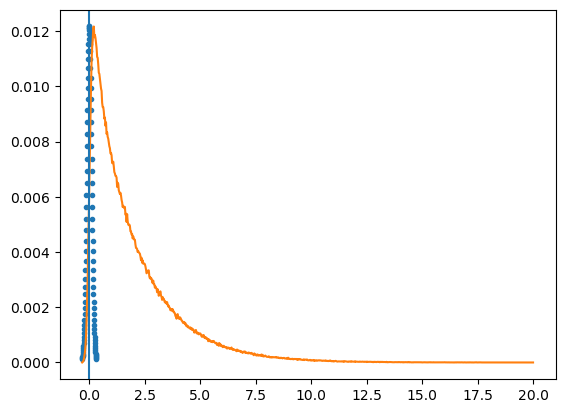

In [63]:

resolution_factor = N_frac.max()/lt_resolution.evaluate(np.linspace(-3*irf_sigma,3*irf_sigma, 100)).max()
plt.plot(np.linspace(-3*irf_sigma,3*irf_sigma, 100), resolution_factor*lt_resolution.evaluate(np.linspace(-3*irf_sigma,3*irf_sigma, 100)),'.')
#plt.semilogy(time, simulated_lt_spectrum.lifetime/simulated_lt_spectrum.lifetime.sum(),'.')
#plt.semilogy(time, pyPAS_N_frac.lifetime,'.', label='analytical')
plt.plot(t, N_frac, label='MC')
#plt.ylim([1e-5, 2*np.max(evaluate)])
plt.axvline(0)

In [75]:
dt        = 0.025
irf_sigma = 0.250 / (2*np.sqrt(2*np.log(2)))
t_pre     = 3 * irf_sigma
n_pre     = int(round(t_pre / dt))

# Define t ONCE — everything else is derived from it
t         = np.arange(-t_pre, 20, dt)
n_t       = len(t)

# IRF kernel (on its own grid, for convolution)
irf_t      = np.arange(-4*irf_sigma, 4*irf_sigma + dt, dt)
irf_kernel = np.exp(-0.5*(irf_t/irf_sigma)**2)
irf_kernel /= irf_kernel.sum()
n_half     = len(irf_kernel) // 2

# Decay on t>=0 only
t_int  = np.arange(0, 20, dt)
decay  = sum(I*np.exp(-t_int/tau) for tau,I in zip(true_taus, true_I))

# Full convolution, cut to match t exactly
raw    = fftconvolve(decay, irf_kernel, mode='full')
signal = raw[n_half - n_pre : n_half - n_pre + n_t]

N_measured   = np.random.poisson(
    signal/signal.sum()*total_counts
).astype(float)
N_frac = N_measured / N_measured.sum()


In [76]:
len(t)

813

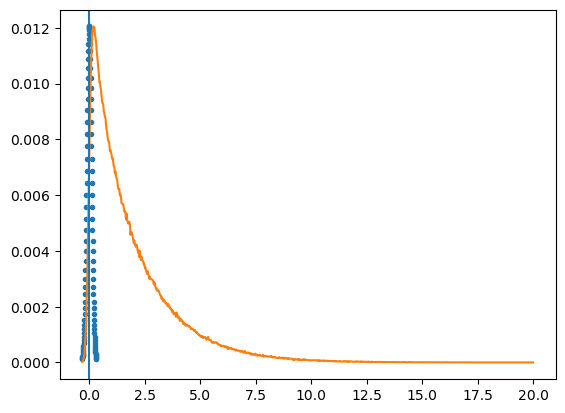

In [77]:

resolution_factor = N_frac.max()/lt_resolution.evaluate(np.linspace(-3*irf_sigma,3*irf_sigma, 100)).max()
plt.plot(np.linspace(-3*irf_sigma,3*irf_sigma, 100), resolution_factor*lt_resolution.evaluate(np.linspace(-3*irf_sigma,3*irf_sigma, 100)),'.')
#plt.semilogy(time, simulated_lt_spectrum.lifetime/simulated_lt_spectrum.lifetime.sum(),'.')
#plt.semilogy(time, pyPAS_N_frac.lifetime,'.', label='analytical')
plt.plot(t, N_frac, label='MC')
#plt.ylim([1e-5, 2*np.max(evaluate)])
plt.axvline(0)

In [41]:
irf_sigma

0.10616522503600238

IRF peak at:    t = 0.0000 ns
Signal peak at: t = 0.5750 ns
Shift:          0.5750 ns  (should be ~0)
Done.


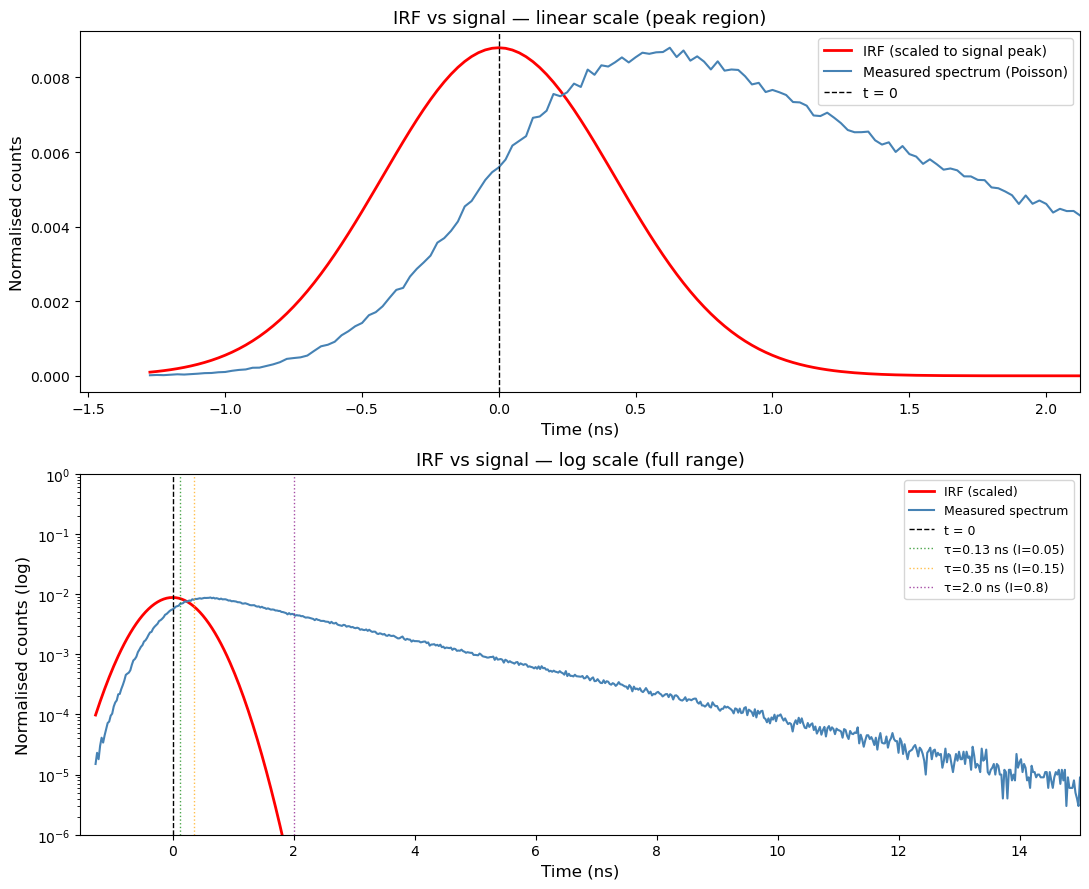

In [59]:
import numpy as np
from scipy.ndimage import convolve1d
import matplotlib.pyplot as plt

np.random.seed(42)

# ═══════════════════════════════════════════════════════════════════════════
# PARAMETERS
# ═══════════════════════════════════════════════════════════════════════════
dt           = 0.025
irf_sigma    = 4 * 0.250 / (2*np.sqrt(2*np.log(2)))   # ~0.425 ns
t_pre        = 3 * irf_sigma                            # pre-peak window
total_counts = 1_000_000

true_taus = np.array([0.130, 0.350, 2.0])
true_I    = np.array([0.05,  0.15,  0.80])

# ═══════════════════════════════════════════════════════════════════════════
# TIME AXIS — includes pre-peak region
# ═══════════════════════════════════════════════════════════════════════════
t   = np.concatenate([np.arange(-t_pre, 0, dt), np.arange(0, 20, dt)])
n_t = len(t)

# ═══════════════════════════════════════════════════════════════════════════
# IRF KERNEL — symmetric Gaussian, centered at its own midpoint
# Built on a separate fine grid, then used as convolve1d kernel
# ═══════════════════════════════════════════════════════════════════════════
irf_t      = np.arange(-4*irf_sigma, 4*irf_sigma + dt, dt)
irf_kernel = np.exp(-0.5*(irf_t/irf_sigma)**2)
irf_kernel /= irf_kernel.sum()

# IRF evaluated on the main time axis (for plotting only)
irf_on_t   = np.exp(-0.5*(t/irf_sigma)**2)
irf_on_t  /= irf_on_t.sum()

# ═══════════════════════════════════════════════════════════════════════════
# DECAY — physical (t>0 only)
# ═══════════════════════════════════════════════════════════════════════════
decay           = sum(I*np.exp(-t/tau) for tau,I in zip(true_taus, true_I))
decay[t <= 0]   = 0.0

# ═══════════════════════════════════════════════════════════════════════════
# CONVOLVE — convolve1d keeps output on same time axis, no shift
# ═══════════════════════════════════════════════════════════════════════════
signal_conv = convolve1d(decay, irf_kernel, mode='constant', cval=0.0)
signal_conv = np.maximum(signal_conv, 0)

# Poisson noise
N_measured  = np.random.poisson(
    signal_conv / signal_conv.sum() * total_counts
).astype(float)
N_frac      = N_measured / N_measured.sum()

# ═══════════════════════════════════════════════════════════════════════════
# VERIFY ALIGNMENT
# ═══════════════════════════════════════════════════════════════════════════
peak_irf    = t[np.argmax(irf_on_t)]
peak_signal = t[np.argmax(signal_conv)]
print(f"IRF peak at:    t = {peak_irf:.4f} ns")
print(f"Signal peak at: t = {peak_signal:.4f} ns")
print(f"Shift:          {peak_signal - peak_irf:.4f} ns  (should be ~0)")

# ═══════════════════════════════════════════════════════════════════════════
# PLOT
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 1, figsize=(11, 9))

# Scale IRF to match signal peak for visual comparison
scale = N_frac.max() / irf_on_t.max()

# ── Linear scale (zoom on peak region) ───────────────────────────────────
ax = axes[0]
ax.plot(t, irf_on_t * scale, color='red',       lw=2,   label='IRF (scaled to signal peak)')
ax.plot(t, N_frac,           color='steelblue', lw=1.5, label='Measured spectrum (Poisson)')
ax.axvline(0, color='k', lw=1, ls='--', label='t = 0')
ax.set_xlim(-t_pre*1.2, 5*irf_sigma)
ax.set_xlabel('Time (ns)', fontsize=12)
ax.set_ylabel('Normalised counts', fontsize=12)
ax.set_title('IRF vs signal — linear scale (peak region)', fontsize=13)
ax.legend()

# ── Log scale (full range) ────────────────────────────────────────────────
ax = axes[1]
ax.semilogy(t, irf_on_t * scale, color='red',       lw=2,   label='IRF (scaled)')
ax.semilogy(t, N_frac,           color='steelblue', lw=1.5, label='Measured spectrum')
ax.axvline(0, color='k', lw=1, ls='--', label='t = 0')

# Mark true tau positions
for tau, I, color in zip(true_taus, true_I, ['green', 'orange', 'purple']):
    ax.axvline(tau, color=color, lw=1, ls=':', alpha=0.7, label=f'τ={tau} ns (I={I})')

ax.set_xlim(-t_pre*1.2, 15)
ax.set_ylim(1e-6, 1)
ax.set_xlabel('Time (ns)', fontsize=12)
ax.set_ylabel('Normalised counts (log)', fontsize=12)
ax.set_title('IRF vs signal — log scale (full range)', fontsize=13)
ax.legend(fontsize=9)

plt.tight_layout()
print("Done.")